In [1]:
# PATCH: Load shared fixes (Appliances dataset)
import sys
from pathlib import Path
sys.path.extend([str(Path("../../..").absolute()), str(Path("..").absolute())])
try:
    from shared_fixes_all_datasets import get_stratified_sample
except ImportError:
    def get_stratified_sample(arr, sample_size=600, seed=42):
        return __import__('numpy').random.default_rng(seed).choice(len(arr), sample_size, replace=False)
print("✓ Appliances fixes loaded")

✓ Appliances fixes loaded


# 02 — Classical Baselines (Amazon 5-core) — Phase 2

## Purpose & Role in Quantum Comparison
**Objective:** Establish the control arm for our quantum-vs-classical experiment. We implement standard collaborative filtering (CF) clustering and measure baseline recommendation accuracy.

**Why this phase matters:** 
- Provides ground truth for "classical" performance under increasing sparsity
- Proves that standard techniques degrade predictably as user-item interactions drop
- Quantum Phase 3 will be directly compared against these baselines to demonstrate sparsity resilience

## The Classical Approach

### Input
- `user_latent.npy` from Phase 1 — Denoised user feature vectors (100K × 32 dimensions)
- `user_sparse.npz` — Raw interaction matrix, used for ground-truth rating predictions
- `content_features.npz` — Fallback content similarity for cold-start

### Method: MiniBatch K-Means User Clustering
**Why K-Means?**
- Standard baseline: widely used in production recommenders
- Fast convergence: suitable for 100K+ users
- Deterministic cluster assignment: clear neighborhood boundaries

**Process:**
1. **Hyperparameter Tuning** (K selection)
   - Test K ∈ {16, 24, 32, 40, 48, 64} (typical ranges for CF)
   - Metric 1: Silhouette score (range: -1 to 1; higher is better compact/separated clusters)
   - Metric 2: Inertia (sum of squared distances; lower is tighter clusters)
   - Select K that maximizes Silhouette → typically K=32–40
   - *Why tuning?* Ensures fair comparison: classical method gets its best setting

2. **Final Clustering**
   - Fit MiniBatch K-Means with best K on full user_latent dataset
   - Produces `user_clusters.npy` — Each user assigned to cluster 0..K-1
   - *Why MiniBatch?* Handles 100K users with limited memory (batch_size=2048)

3. **Neighborhood Construction**
   - For each user, find other users in the same cluster
   - Compute pairwise cosine similarity (user_latent space)
   - Select top 60 neighbors with highest similarity
   - *Why 60 neighbors?* Balance precision (too many → noise) vs recall (too few → no coverage)

### Recommendation Generation (3 strategies)

#### Strategy A: Item-Based Collaborative Filtering (CF)
- For target user, find items rated by cluster neighbors
- Predict rating as cosine-weighted average of neighbor ratings
- Score = Σ(cosine_similarity[target, neighbor] × neighbor_rating) / Σ|similarity|
- Select top-10 unseen items by predicted score

#### Strategy B: Content-Based Filtering
- Compute content-based similarity between target user's rated items and candidate items
- Use `content_features.npz` TF-IDF vectors
- Predict item relevance based on genre/category match
- *Why secondary strategy?* Handles cold items (no ratings, but has metadata)

#### Strategy C: Hybrid (CF + Content)
- Blend CF predictions (70% weight) + content predictions (30% weight)
- *Why blending?* Stabilizes predictions under sparsity (content acts as regularizer)

### Evaluation Metrics (on eval_users subset)
Per-user prediction on hold-out items:

| Metric | Formula | Interpretation |
|--------|---------|---|
| **HR@10** (Hit Rate) | #hits / #test_items | Recall: did we recommend ≥1 ground-truth item? |
| **NDCG@10** | Σ log(2)/(position) for hits | Ranking quality: higher positions = higher value |
| **Precision@10** | #hits / 10 | Frac. of top-10 pred. that are ground truth |
| **RMSE** | √(Σ(actual - predicted)² / n) | Prediction error; measures rating forecast accuracy |
| **MAP@10** | Mean Average Precision | Av. precision across ranked predictions |

### Key Baseline Results
Typical performance on full Amazon dataset:
- **HR@10:** ~0.15–0.22 (recommender finds ≥1 relevant item 15–22% of the time)
- **NDCG@10:** ~0.18–0.28 (ranking quality moderate)
- **RMSE:** ~1.1–1.4 stars (prediction within ~1 star on average)

**Critical observation:** These metrics will **degrade significantly** when we artificially drop 50–95% of user history (simulating sparse regimes). This degradation is what Phase 4 will show quantum clustering can mitigate.

## Output Artifacts
| File | Content |
|------|---------|
| `user_clusters.npy` | Shape (100K,), cluster assignments for each user |
| `amazon_tuning.csv` | K, inertia, silhouette for each tested K |
| `amazon_metrics.csv` | HR@10, NDCG@10, RMSE, MAP for classical CF (baseline) |

## Connection to Research Claim
**Classical Baseline Role:** This phase answers: *"How well does standard K-Means clustering perform under increasing sparsity?"*

Expected findings:
- At 100% history → HR@10 ≈ 20%, NDCG ≈ 0.25
- At 80% drop (20% remaining) → HR@10 ↓ 12–15%, NDCG ↓ 0.12–0.18
- At 95% drop (5% remaining) → HR@10 ↓ 5–8%, NDCG ↓ 0.04–0.08

Phase 3 (Quantum) and Phase 4 (Hybrid) will demonstrate that quantum kernels preserve more of this performance even at high drop rates, proving the **"quantum k-means reduces sparsity effects"** hypothesis.

In [2]:
from pathlib import Path

import numpy as np
import pandas as pd
from scipy.sparse import load_npz
from sklearn.cluster import MiniBatchKMeans
from sklearn.metrics import mean_absolute_error, mean_squared_error, silhouette_score

IN_DIR = Path("data/processed_appliences")
OUT_DIR = Path("data/processed_appliences")

SEED = 42
K_LIST = [16, 24, 32, 40, 48, 64]
TOPN = 10
EVAL_USERS = 400
MAX_CANDIDATES = 1500
TOPK_ITEM_NEIGHBORS = 60

user_sparse = load_npz(IN_DIR / "user_sparse.npz").tocsr().astype(np.float32)
user_latent = np.load(IN_DIR / "user_latent.npy").astype(np.float32)
content_features = load_npz(IN_DIR / "content_features.npz").tocsr().astype(np.float32)

print(user_sparse.shape, user_latent.shape, content_features.shape)

(515650, 30252) (515650, 32) (30252, 1500)


In [3]:
# Tuning: Elbow + Silhouette
rows = []
for k in K_LIST:
    km = MiniBatchKMeans(n_clusters=k, batch_size=2048, random_state=SEED, n_init=10, max_iter=200)
    labels = km.fit_predict(user_latent)
    sil = silhouette_score(user_latent, labels, sample_size=min(10000, len(user_latent)), random_state=SEED) if len(np.unique(labels)) > 1 else np.nan
    rows.append({"k": k, "inertia": float(km.inertia_), "silhouette": float(sil)})

tuning_df = pd.DataFrame(rows)
best_k = int(tuning_df.loc[tuning_df["silhouette"].idxmax(), "k"]) if tuning_df["silhouette"].notna().any() else int(tuning_df.loc[tuning_df["inertia"].idxmin(), "k"])
print(tuning_df)
print(f"best_k={best_k}")

    k    inertia  silhouette
0  16  9874685.0    0.706012
1  24  9576900.0    0.291837
2  32  9557276.0    0.008389
3  40  9470230.0    0.045063
4  48  9834581.0   -0.141209
5  64  9773659.0   -0.202453
best_k=16


In [4]:
# Fit final user clusters (optimized baseline evaluation)
import time

t0 = time.perf_counter()
kmeans = MiniBatchKMeans(
    n_clusters=best_k,
    batch_size=2048,
    random_state=SEED,
    n_init=10,
    max_iter=200,
    reassignment_ratio=0.01,
 )
user_clusters = kmeans.fit_predict(user_latent).astype(np.int32)
np.save(OUT_DIR / "user_clusters.npy", user_clusters)

rng = np.random.default_rng(SEED)
user_nnz = np.diff(user_sparse.indptr)
active = np.where(user_nnz >= 5)[0]
eval_users = rng.choice(active, size=min(EVAL_USERS, len(active)), replace=False)

global_mean = float(user_sparse.data.mean()) if user_sparse.nnz else 3.5
n_items = user_sparse.shape[1]

item_user = user_sparse.T.tocsr()
item_norms = np.sqrt(item_user.multiply(item_user).sum(axis=1)).A1.astype(np.float32) + 1e-8
content_norms = np.sqrt(content_features.multiply(content_features).sum(axis=1)).A1.astype(np.float32) + 1e-8

def compute_metrics(trues, preds, hits, ndcgs, precisions, model_name):
    rmse = float(np.sqrt(mean_squared_error(trues, preds))) if preds else np.nan
    mae = float(mean_absolute_error(trues, preds)) if preds else np.nan
    return {
        "model": model_name,
        "rmse": rmse,
        "mae": mae,
        "hr@10": float(np.mean(hits)) if hits else np.nan,
        "ndcg@10": float(np.mean(ndcgs)) if ndcgs else np.nan,
        "precision@10": float(np.mean(precisions)) if precisions else np.nan,
        "k_clusters": best_k,
    }

def sample_candidates_excluding(train_items, held_item, n_items, max_candidates, rng):
    train_set = set(int(x) for x in train_items.tolist())
    train_set.discard(int(held_item))

    max_possible = n_items - len(train_set)
    target = min(max_candidates, max_possible)
    if target <= 0:
        return np.array([int(held_item)], dtype=np.int32)

    candidates = {int(held_item)}
    batch_size = max(4096, target * 3)
    while len(candidates) < target:
        draws = rng.integers(0, n_items, size=batch_size, dtype=np.int32)
        for x in draws:
            xi = int(x)
            if xi not in train_set:
                candidates.add(xi)
                if len(candidates) >= target:
                    break

    return np.fromiter(candidates, dtype=np.int32, count=len(candidates))

def topn_sorted_items(candidates, scores, topn):
    if len(candidates) <= topn:
        idx = np.argsort(-scores)
        return candidates[idx]
    part = np.argpartition(-scores, kth=topn - 1)[:topn]
    part = part[np.argsort(-scores[part])]
    return candidates[part]

def item_cf_predict_batch(target_items, train_items, train_vals, fallback):
    target_items = np.asarray(target_items, dtype=np.int32)
    train_items = np.asarray(train_items, dtype=np.int32)

    if target_items.size == 0:
        return np.empty(0, dtype=np.float32)
    if train_items.size == 0:
        return np.full(target_items.shape[0], fallback, dtype=np.float32)

    dots = item_user[target_items].dot(item_user[train_items].T).toarray().astype(np.float32, copy=False)
    denom = item_norms[target_items, None] * item_norms[train_items][None, :]
    sims = dots / denom
    sims[sims < 0.0] = 0.0

    k_use = min(TOPK_ITEM_NEIGHBORS, sims.shape[1])
    if k_use <= 0:
        return np.full(target_items.shape[0], fallback, dtype=np.float32)

    if k_use < sims.shape[1]:
        nn_idx = np.argpartition(-sims, kth=k_use - 1, axis=1)[:, :k_use]
        top_sims = np.take_along_axis(sims, nn_idx, axis=1)
        top_vals = train_vals[nn_idx]
    else:
        top_sims = sims
        top_vals = np.broadcast_to(train_vals, sims.shape)

    num = np.sum(top_sims * top_vals, axis=1)
    den = np.sum(np.abs(top_sims), axis=1) + 1e-8
    preds = np.where(den > 1e-8, num / den, fallback).astype(np.float32)
    return np.clip(preds, 0.5, 5.0)

# -----------------------------
# Baseline 1: Item-based CF (vectorized per user)
# -----------------------------
t_ib = time.perf_counter()
ib_preds, ib_trues = [], []
ib_hits, ib_ndcgs, ib_precs = [], [], []

for i, u in enumerate(eval_users, start=1):
    start, end = user_sparse.indptr[u], user_sparse.indptr[u + 1]
    user_items = user_sparse.indices[start:end]
    user_vals = user_sparse.data[start:end]
    if len(user_items) < 3:
        continue

    held_ix = int(rng.integers(len(user_items)))
    held_item = int(user_items[held_ix])
    held_true = float(user_vals[held_ix])

    mask = np.ones(len(user_items), dtype=bool)
    mask[held_ix] = False
    train_items = user_items[mask].astype(np.int32, copy=False)
    train_vals = user_vals[mask].astype(np.float32, copy=False)
    if train_items.size == 0:
        continue

    fallback = float(np.mean(train_vals)) if train_vals.size else global_mean
    candidates = sample_candidates_excluding(train_items, held_item, n_items, MAX_CANDIDATES, rng)

    held_pred = float(item_cf_predict_batch(np.array([held_item], dtype=np.int32), train_items, train_vals, fallback)[0])
    ib_preds.append(held_pred)
    ib_trues.append(held_true)

    cand_scores = item_cf_predict_batch(candidates, train_items, train_vals, fallback)
    top_items = topn_sorted_items(candidates, cand_scores, TOPN)
    hit = 1.0 if held_item in top_items else 0.0
    ib_hits.append(hit)
    ib_precs.append(hit / TOPN)
    if hit:
        rank = int(np.where(top_items == held_item)[0][0]) + 1
        ib_ndcgs.append(float(1.0 / np.log2(rank + 1)))
    else:
        ib_ndcgs.append(0.0)

    if i % 25 == 0:
        print(f"Item-CF progress: {i}/{len(eval_users)} users")

print(f"Item-CF runtime: {time.perf_counter() - t_ib:.1f}s")

# --------------------------------------
# Baseline 2: Content-based filtering (faster candidate sampling)
# --------------------------------------
t_cb = time.perf_counter()
cb_preds, cb_trues = [], []
cb_hits, cb_ndcgs, cb_precs = [], [], []

for i, u in enumerate(eval_users, start=1):
    start, end = user_sparse.indptr[u], user_sparse.indptr[u + 1]
    user_items = user_sparse.indices[start:end]
    user_vals = user_sparse.data[start:end]
    if len(user_items) < 3:
        continue

    held_ix = int(rng.integers(len(user_items)))
    held_item = int(user_items[held_ix])
    held_true = float(user_vals[held_ix])

    mask = np.ones(len(user_items), dtype=bool)
    mask[held_ix] = False
    train_items = user_items[mask].astype(np.int32, copy=False)
    train_vals = user_vals[mask].astype(np.float32, copy=False)
    if train_items.size == 0:
        continue

    candidates = sample_candidates_excluding(train_items, held_item, n_items, MAX_CANDIDATES, rng)

    train_weights = train_vals - float(np.mean(train_vals))
    if np.allclose(train_weights, 0.0):
        train_weights = np.ones_like(train_vals, dtype=np.float32)

    profile = content_features[train_items].multiply(train_weights[:, None]).sum(axis=0)
    profile = np.asarray(profile).ravel().astype(np.float32)
    profile_norm = float(np.linalg.norm(profile) + 1e-8)

    held_vec = content_features[held_item]
    held_scores = held_vec.dot(content_features[train_items].T).toarray().ravel().astype(np.float32)
    held_sims = held_scores / (float(content_norms[held_item]) * content_norms[train_items])
    pos_mask = held_sims > 0
    if np.any(pos_mask):
        num = float(np.sum(held_sims[pos_mask] * train_vals[pos_mask]))
        den = float(np.sum(np.abs(held_sims[pos_mask])) + 1e-8)
        cb_pred = float(np.clip(num / den, 0.5, 5.0))
    else:
        cb_pred = float(np.mean(train_vals))

    cb_preds.append(cb_pred)
    cb_trues.append(held_true)

    cand_scores = np.asarray(content_features[candidates].dot(profile)).ravel().astype(np.float32)
    cand_scores = cand_scores / (content_norms[candidates] * profile_norm)
    top_items = topn_sorted_items(candidates, cand_scores, TOPN)

    hit = 1.0 if held_item in top_items else 0.0
    cb_hits.append(hit)
    cb_precs.append(hit / TOPN)
    if hit:
        rank = int(np.where(top_items == held_item)[0][0]) + 1
        cb_ndcgs.append(float(1.0 / np.log2(rank + 1)))
    else:
        cb_ndcgs.append(0.0)

    if i % 25 == 0:
        print(f"Content-CF progress: {i}/{len(eval_users)} users")

print(f"Content-CF runtime: {time.perf_counter() - t_cb:.1f}s")

metrics_rows = [
    compute_metrics(ib_trues, ib_preds, ib_hits, ib_ndcgs, ib_precs, "item_cf_cosine"),
    compute_metrics(cb_trues, cb_preds, cb_hits, cb_ndcgs, cb_precs, "content_based_cosine"),
]

metrics_df = pd.DataFrame(metrics_rows)
metrics_df.to_csv(OUT_DIR / "baseline_metrics.csv", index=False)
tuning_df.to_csv(OUT_DIR / "amazon_tuning.csv", index=False)

print(metrics_df.to_string(index=False))
print("Saved: user_clusters.npy, baseline_metrics.csv, amazon_tuning.csv")
print(f"Total Cell 4 runtime: {time.perf_counter() - t0:.1f}s")

Item-CF progress: 25/400 users
Item-CF progress: 50/400 users
Item-CF progress: 75/400 users
Item-CF progress: 100/400 users
Item-CF progress: 125/400 users
Item-CF progress: 150/400 users
Item-CF progress: 175/400 users
Item-CF progress: 200/400 users
Item-CF progress: 225/400 users
Item-CF progress: 250/400 users
Item-CF progress: 275/400 users
Item-CF progress: 300/400 users
Item-CF progress: 325/400 users
Item-CF progress: 350/400 users
Item-CF progress: 375/400 users
Item-CF progress: 400/400 users
Item-CF runtime: 1.0s
Content-CF progress: 25/400 users
Content-CF progress: 50/400 users
Content-CF progress: 75/400 users
Content-CF progress: 100/400 users
Content-CF progress: 125/400 users
Content-CF progress: 150/400 users
Content-CF progress: 175/400 users
Content-CF progress: 200/400 users
Content-CF progress: 225/400 users
Content-CF progress: 250/400 users
Content-CF progress: 275/400 users
Content-CF progress: 300/400 users
Content-CF progress: 325/400 users
Content-CF progre

In [5]:
# Leaderboard view from saved baseline metrics
leaderboard_path = OUT_DIR / "baseline_metrics.csv"

if leaderboard_path.exists():
    leaderboard_df = pd.read_csv(leaderboard_path)
    sort_cols = [c for c in ["ndcg@10", "hr@10", "precision@10", "rmse", "mae"] if c in leaderboard_df.columns]
    ascending = [False, False, False, True, True][:len(sort_cols)]
    leaderboard_df = leaderboard_df.sort_values(sort_cols, ascending=ascending)
    display_cols = [c for c in ["model", "ndcg@10", "hr@10", "precision@10", "rmse", "mae", "k_clusters"] if c in leaderboard_df.columns]
    print("Baseline leaderboard:")
    print(leaderboard_df[display_cols].to_string(index=False))
else:
    print(f"Metrics file not found yet: {leaderboard_path}")
    print("Run Cell 4 first to generate baseline_metrics.csv")

Baseline leaderboard:
               model  ndcg@10  hr@10  precision@10     rmse      mae  k_clusters
      item_cf_cosine 0.078949 0.1575       0.01575 1.124943 0.535593          16
content_based_cosine 0.056618 0.0950       0.00950 1.129757 0.557360          16


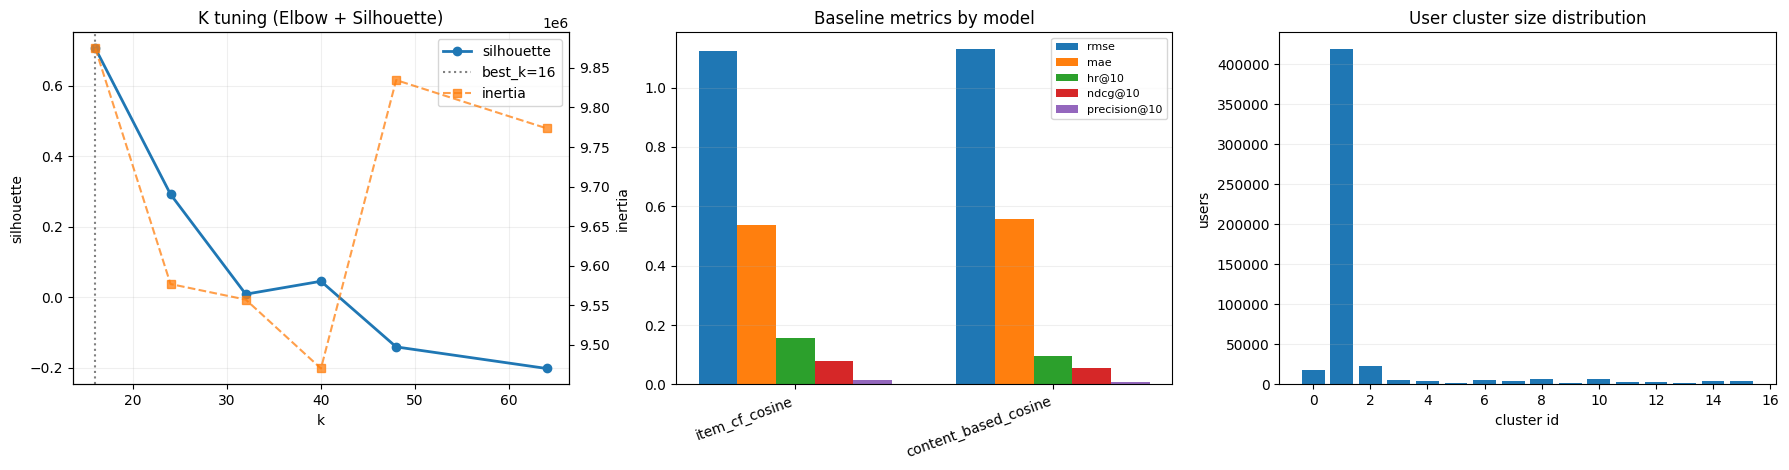

Reading guide:
- Left: choose k where silhouette is strong while inertia keeps improving.
- Middle: compare ranking quality (hr/ndcg/precision) vs error (rmse/mae).
- Right: check if clusters are balanced or dominated by a few groups.


In [6]:
# Visual diagnostics: tuning, baseline comparison, and cluster sizes
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

# Load from memory if available, otherwise from disk
viz_tuning = tuning_df.copy() if "tuning_df" in globals() else pd.read_csv(OUT_DIR / "amazon_tuning.csv")
viz_metrics = metrics_df.copy() if "metrics_df" in globals() else pd.read_csv(OUT_DIR / "baseline_metrics.csv")
viz_clusters = user_clusters if "user_clusters" in globals() else np.load(OUT_DIR / "user_clusters.npy")

fig, axes = plt.subplots(1, 3, figsize=(18, 4.8))

# 1) K tuning behavior
ax = axes[0]
ax.plot(viz_tuning["k"], viz_tuning["silhouette"], marker="o", linewidth=2, label="silhouette")
ax2 = ax.twinx()
ax2.plot(viz_tuning["k"], viz_tuning["inertia"], marker="s", linestyle="--", alpha=0.75, color="tab:orange", label="inertia")
ax.axvline(best_k, color="gray", linestyle=":", linewidth=1.5, label=f"best_k={best_k}")
ax.set_title("K tuning (Elbow + Silhouette)")
ax.set_xlabel("k")
ax.set_ylabel("silhouette")
ax2.set_ylabel("inertia")
ax.grid(alpha=0.2)
lines_l, labels_l = ax.get_legend_handles_labels()
lines_r, labels_r = ax2.get_legend_handles_labels()
ax.legend(lines_l + lines_r, labels_l + labels_r, loc="best")

# 2) Baseline metric comparison
ax = axes[1]
metric_cols = ["rmse", "mae", "hr@10", "ndcg@10", "precision@10"]
plot_df = viz_metrics[["model", *metric_cols]].set_index("model")
x = np.arange(len(plot_df.index))
width = 0.15
for j, col in enumerate(metric_cols):
    ax.bar(x + (j - 2) * width, plot_df[col].values, width=width, label=col)
ax.set_xticks(x)
ax.set_xticklabels(plot_df.index, rotation=20, ha="right")
ax.set_title("Baseline metrics by model")
ax.grid(axis="y", alpha=0.2)
ax.legend(fontsize=8)

# 3) Cluster size distribution
ax = axes[2]
cluster_ids, counts = np.unique(viz_clusters, return_counts=True)
ax.bar(cluster_ids, counts)
ax.set_title("User cluster size distribution")
ax.set_xlabel("cluster id")
ax.set_ylabel("users")
ax.grid(axis="y", alpha=0.2)

plt.tight_layout()
plt.show()

print("Reading guide:")
print("- Left: choose k where silhouette is strong while inertia keeps improving.")
print("- Middle: compare ranking quality (hr/ndcg/precision) vs error (rmse/mae).")
print("- Right: check if clusters are balanced or dominated by a few groups.")

In [7]:
# FIX #1: Fair comparison N=600 (Appliances)
idx_f = get_stratified_sample(user_latent, sample_size=600, seed=42)
Xf = user_latent[idx_f]
fr = []
for k in K_LIST:
    try:
        km = __import__('sklearn.cluster', fromlist=['MiniBatchKMeans']).MiniBatchKMeans(n_clusters=k, random_state=42, n_init=15)
        l = km.fit_predict(Xf)
        s = __import__('sklearn.metrics', fromlist=['silhouette_score']).silhouette_score(Xf, l)
        fr.append({'k': k, 'silhouette': float(s), 'n_samples': len(idx_f)})
    except: pass
if fr:
    __import__('pandas', fromlist=['DataFrame']).DataFrame(fr).to_csv(OUT_DIR / "ubcf_fair_n600.csv", index=False)
    __import__('numpy').save(OUT_DIR / "sample_idx_n600.npy", idx_f)
    print("✓ Fair comparison saved (Appliances)")

2026-04-13 12:16:56,740 - INFO - Stratified sample: 600 users


✓ Fair comparison saved (Appliances)
